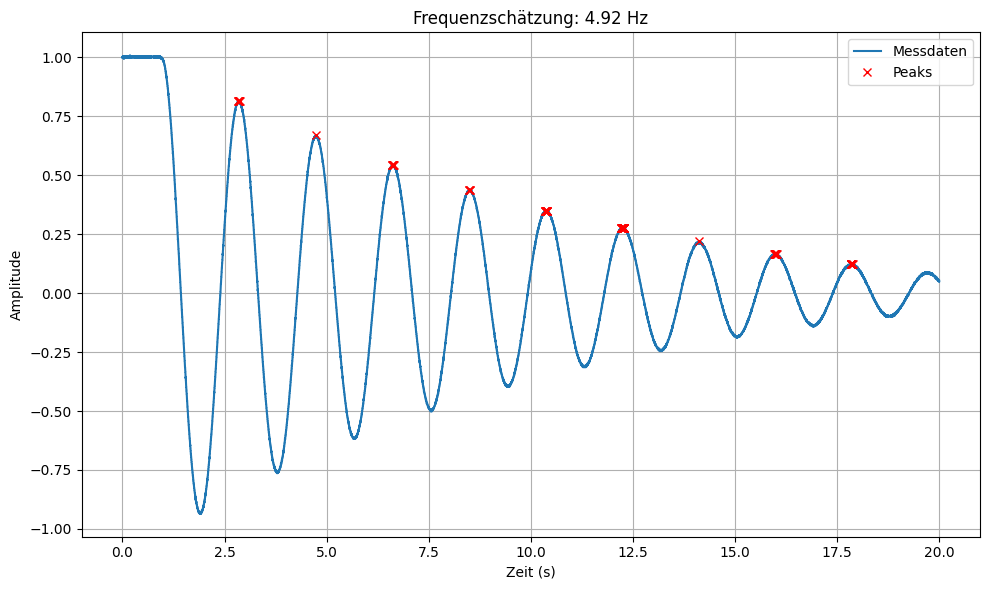

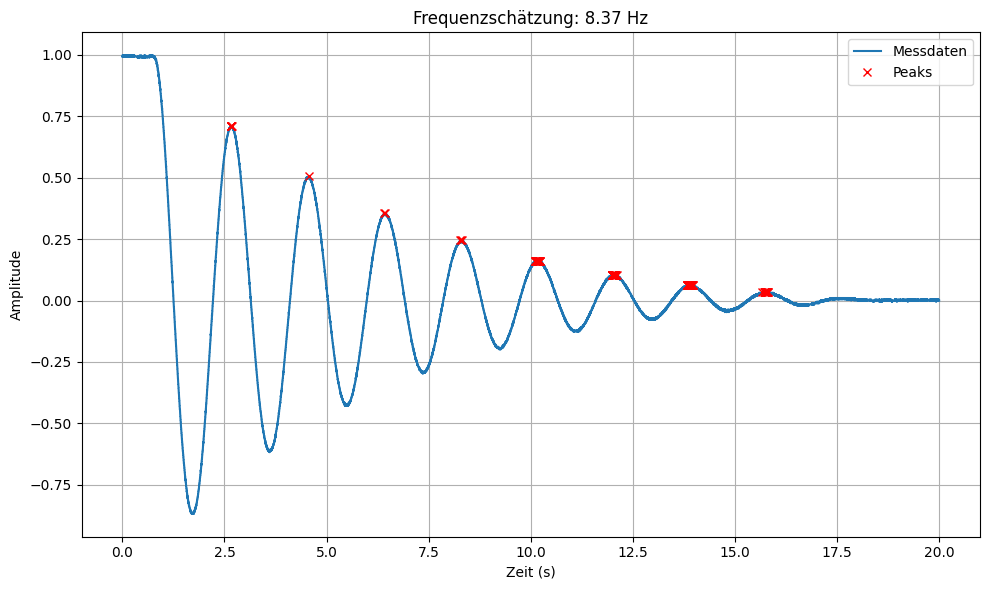

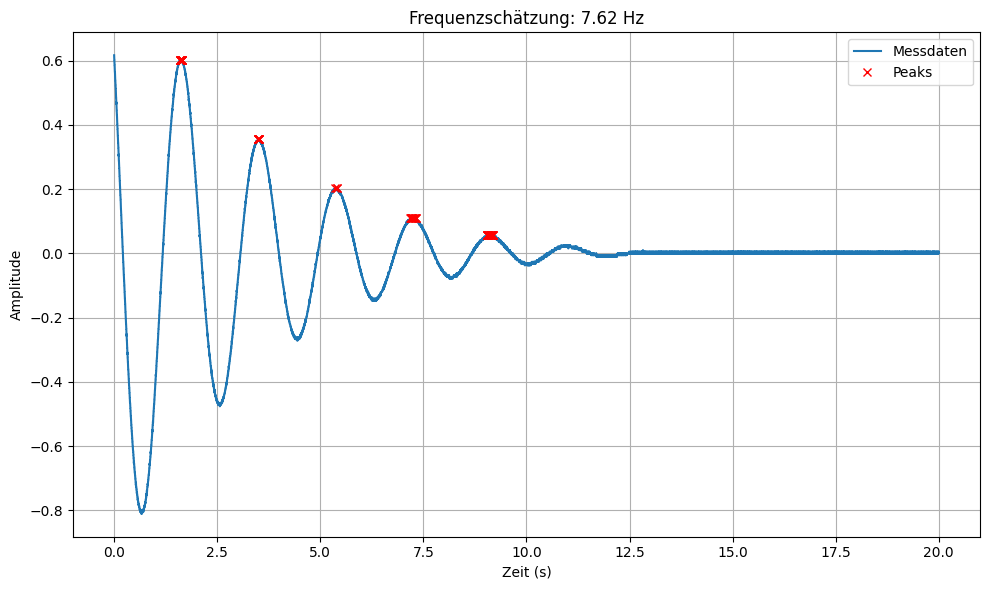

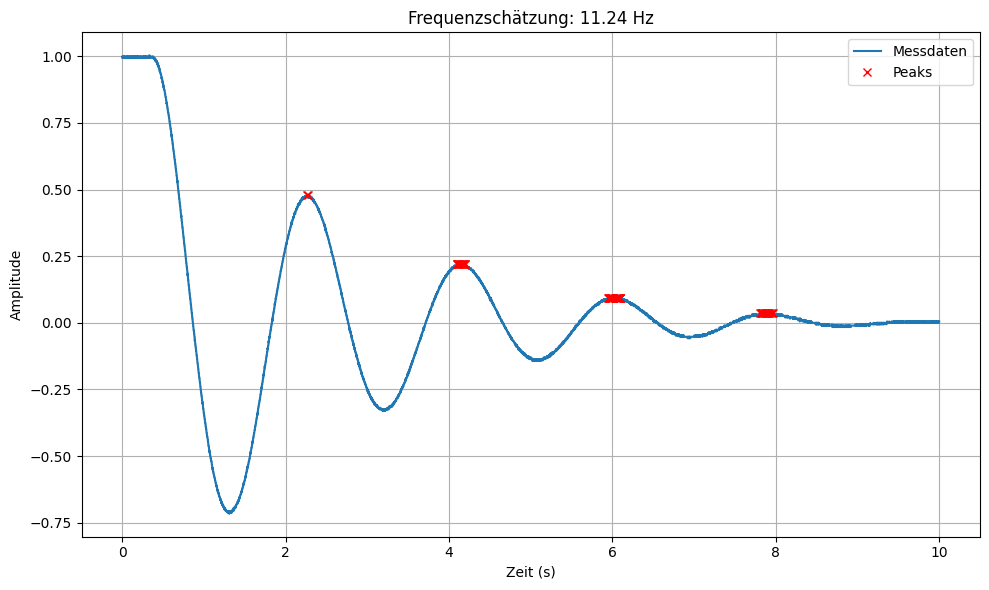

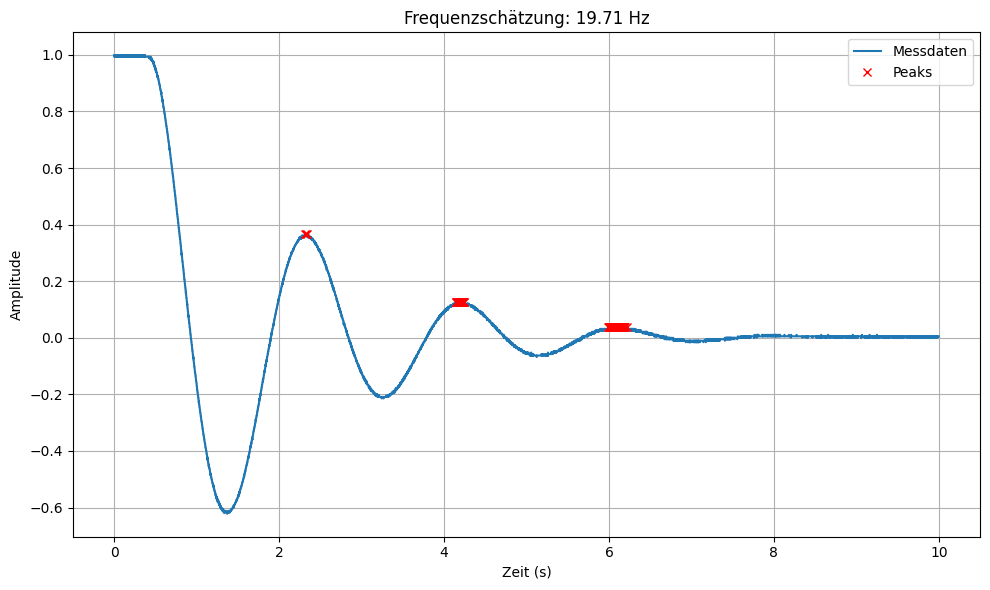

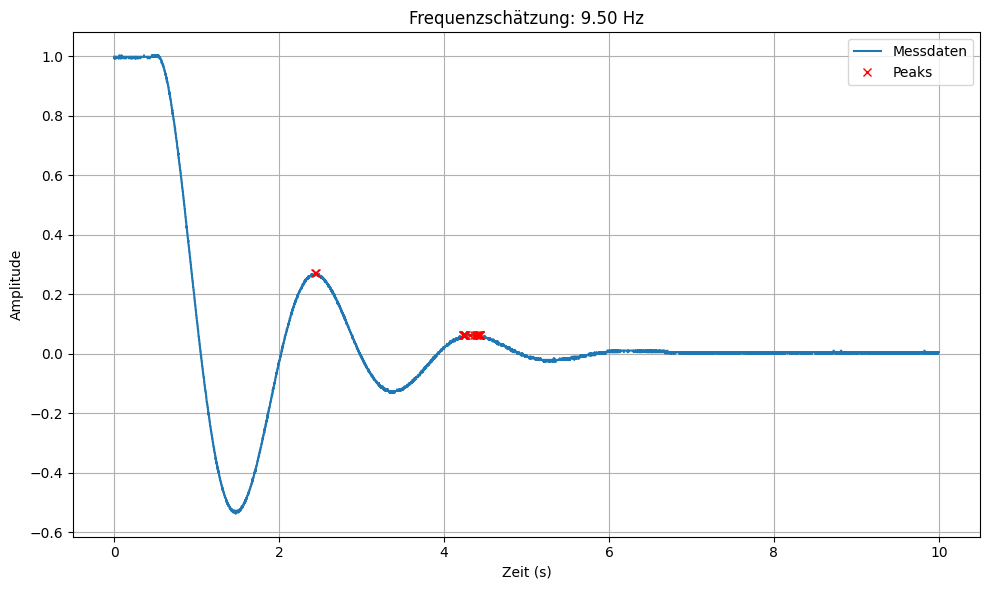

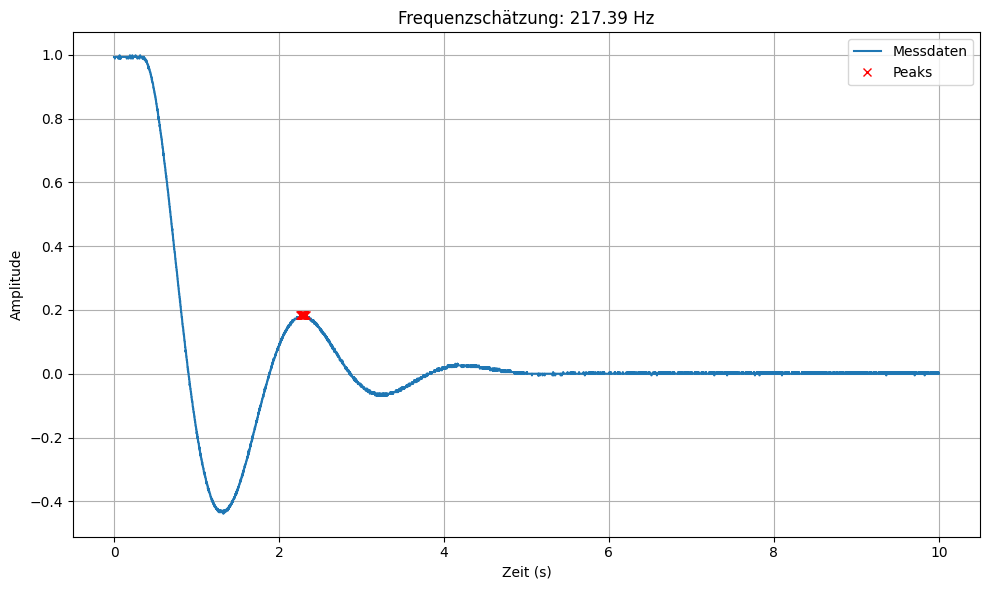

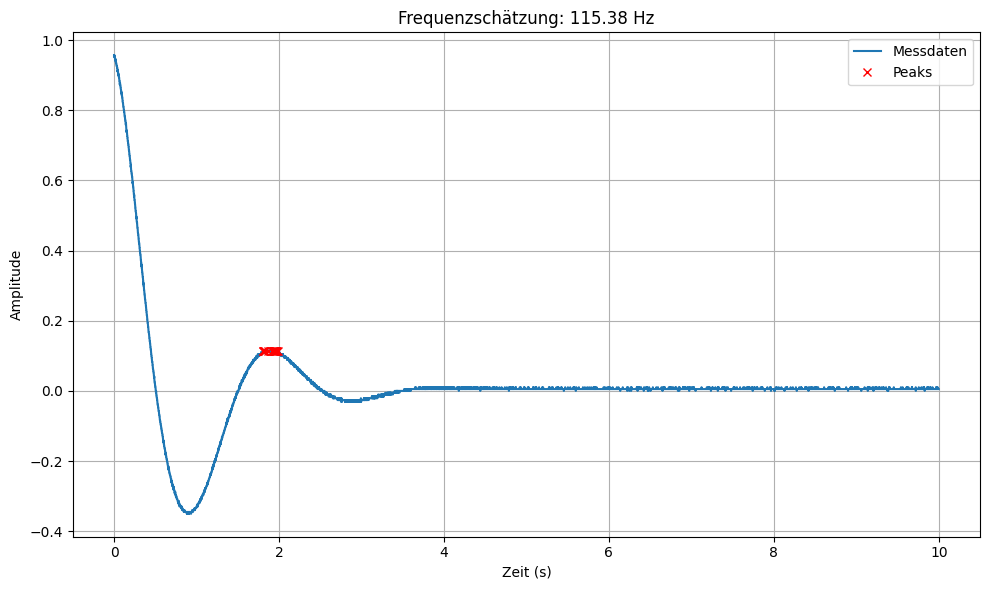

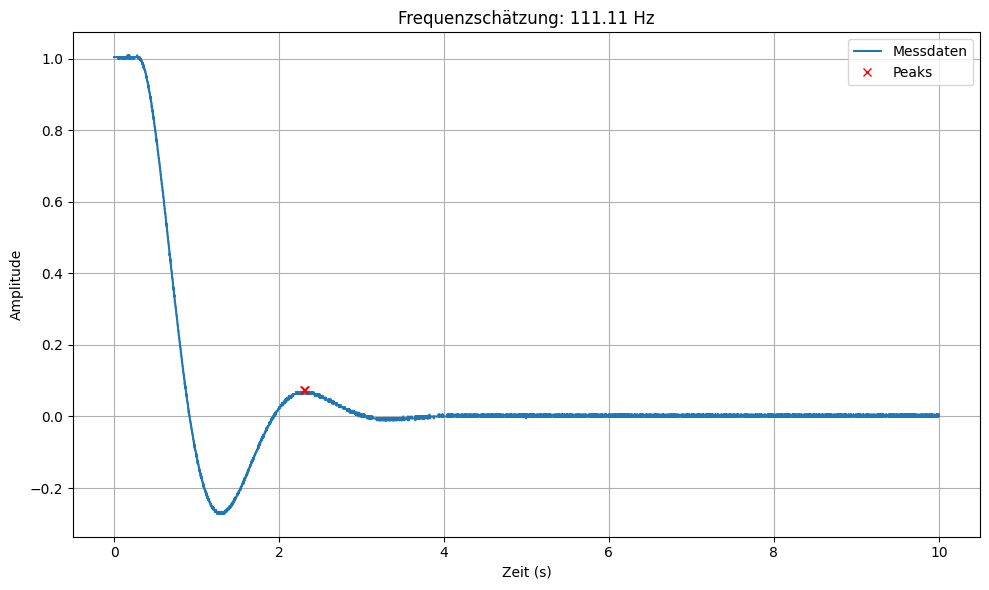

Nicht genug Peaks gefunden.


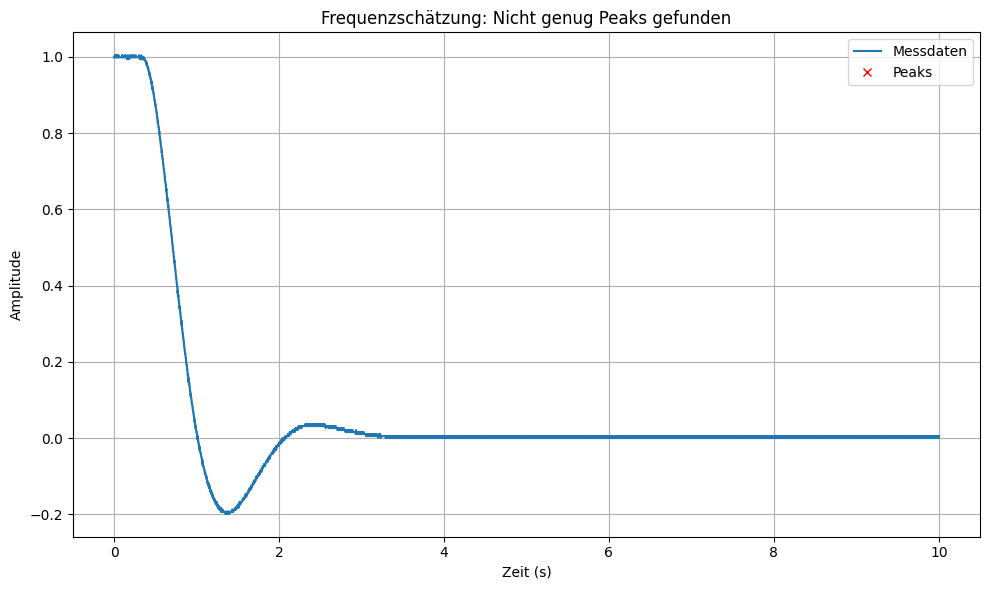

[0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2]
[0.10043302 0.22370614 0.30396591 0.44153998 0.59871191]
[3.25596782 3.18238936 3.32744701 3.23916527 3.12143654 2.87320799
 3.00239735 3.13527212 2.84382818 2.59315714]
[4.916290193994154 8.365655182903643 7.622552240767512 11.237928007023704
 19.713261648745522]


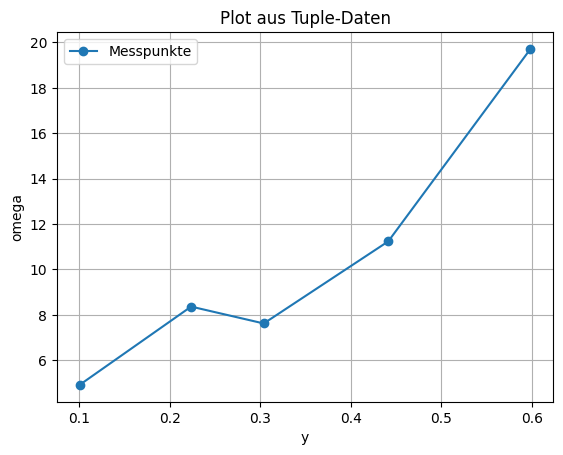

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from natsort import natsorted
import re
from scipy.signal import find_peaks


def extract_numeric_prefix(filename):
    match = re.match(r"(\d+)_(\d+)", filename)
    if match:
        integer_part = match.group(1)
        decimal_part = match.group(2)
        return float(f"{integer_part}.{decimal_part}")
    return None


def damped_sinus_function(x, A, delta, omega, phase, offset):
    return A * np.exp(-delta * x) * np.sin(omega * x + phase) + offset

def estimate_frequency_from_peaks(t, y, prominence=0.05):
    # Finde die Peaks mit definierter Mindestprominenz (Rauschunterdrückung)
    peaks, _ = find_peaks(y, prominence=prominence)
    
    # Wenn weniger als 2 Peaks, Frequenzberechnung nicht möglich
    if len(peaks) < 2:
        print("Nicht genug Peaks gefunden.")
        return None, peaks

    # Zeiten der Peaks
    peak_times = t[peaks]
    
    # Perioden berechnen (Zeitdifferenzen zwischen Peaks)
    periods = np.diff(peak_times)
    
    # Durchschnittliche Periodendauer
    avg_period = np.mean(periods)
    
    # Frequenz in Hz
    frequency = 1 / avg_period
    return frequency, peaks

# Schätzfunktion für omega aus FFT
def estimate_omega_fft(x_data, y_data):
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # überspringe 0-Frequenz
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

# Sinus fitten
def fit_damped_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    delta_guess = 0.1  # Startwert für Dämpfung
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, delta_guess, omega_guess, phase_guess, offset_guess]
    
    params, params_covariance = curve_fit(
        damped_sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    
    fitted_y = damped_sinus_function(x_data, *params)
    return params, fitted_y


# Ordnerpfad anpassen
filepath = "M10_Aufgabe_1_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

# Listen für Amplituden und Omegas
amplitudes_U1 = []
omegas_U1 = []
tuple_delta_file = []
frequency = []
for filename in csv_files:
    df = pd.read_csv(os.path.join(filepath, filename))
    df = df[['t (s)', 'U1(V)']]  # Keep only the required columns

    x = df['t (s)'].values
    y = df['U1(V)'].values

    # Zeit- und Messdaten extrahieren
    t = df.iloc[:, 0].values
    z = df.iloc[:, 1].values
    frequency_wert, peaks = estimate_frequency_from_peaks(t, y)

    paramsU1, fitted_U1 = fit_damped_sinus(x, y)

    Strom = extract_numeric_prefix(filename)

    if Strom is not None:
        tuple_delta_file.append((Strom, paramsU1[1]))
    
    # Speichere absolute Amplitude (ohne Offset)
    amplitudes_U1.append(np.abs(paramsU1[0]))
    omegas_U1.append(paramsU1[2])

    frequency.append(frequency_wert)
    plt.figure(figsize=(10, 6))
    plt.plot(t, y, label="Messdaten")
    plt.plot(t[peaks], y[peaks], "rx", label="Peaks")
    if frequency_wert is not None:
        plt.title(f"Frequenzschätzung: {frequency_wert:.2f} Hz")
    else:
        plt.title("Frequenzschätzung: Nicht genug Peaks gefunden")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    #print(f"File: {filename}")
    #print(f"Amplitude: {np.abs(paramsU1[0])}, Omega: {paramsU1[2]}, Delta: {paramsU1[1]}, Phase: {paramsU1[3]}, Offset: {paramsU1[4]}")

    #plt.figure(figsize=(10, 6))
    #plt.plot(x, y, 'o', label='U1 data')
    #plt.plot(x, fitted_U1, '--', label='U1 fit')
    #plt.xlabel('t (s)')
    #plt.ylabel('Auslenkung')
    #plt.title(filename)
    #plt.legend()
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

#print("Tuple (Strom, Delta):")
#for item in tuple_delta_file:
#    print(item)
 
# Unpack the tuples into two separate lists
x_values, y_values = zip(*tuple_delta_file)
Strom_array = np.array(x_values)
Delta = np.array(y_values)
omegas_U1 = np.array(omegas_U1)
frequency = np.array(frequency)
frequency = frequency[0:5]
Delta = Delta[0:5]

print(Strom_array)
print(Delta)
print(omegas_U1)
print(frequency)

# Plot
plt.plot(Delta, frequency, 'o-', label='Messpunkte')
plt.xlabel('y')
plt.ylabel('omega')
plt.title('Plot aus Tuple-Daten')
plt.grid(True)
plt.legend()
plt.show()


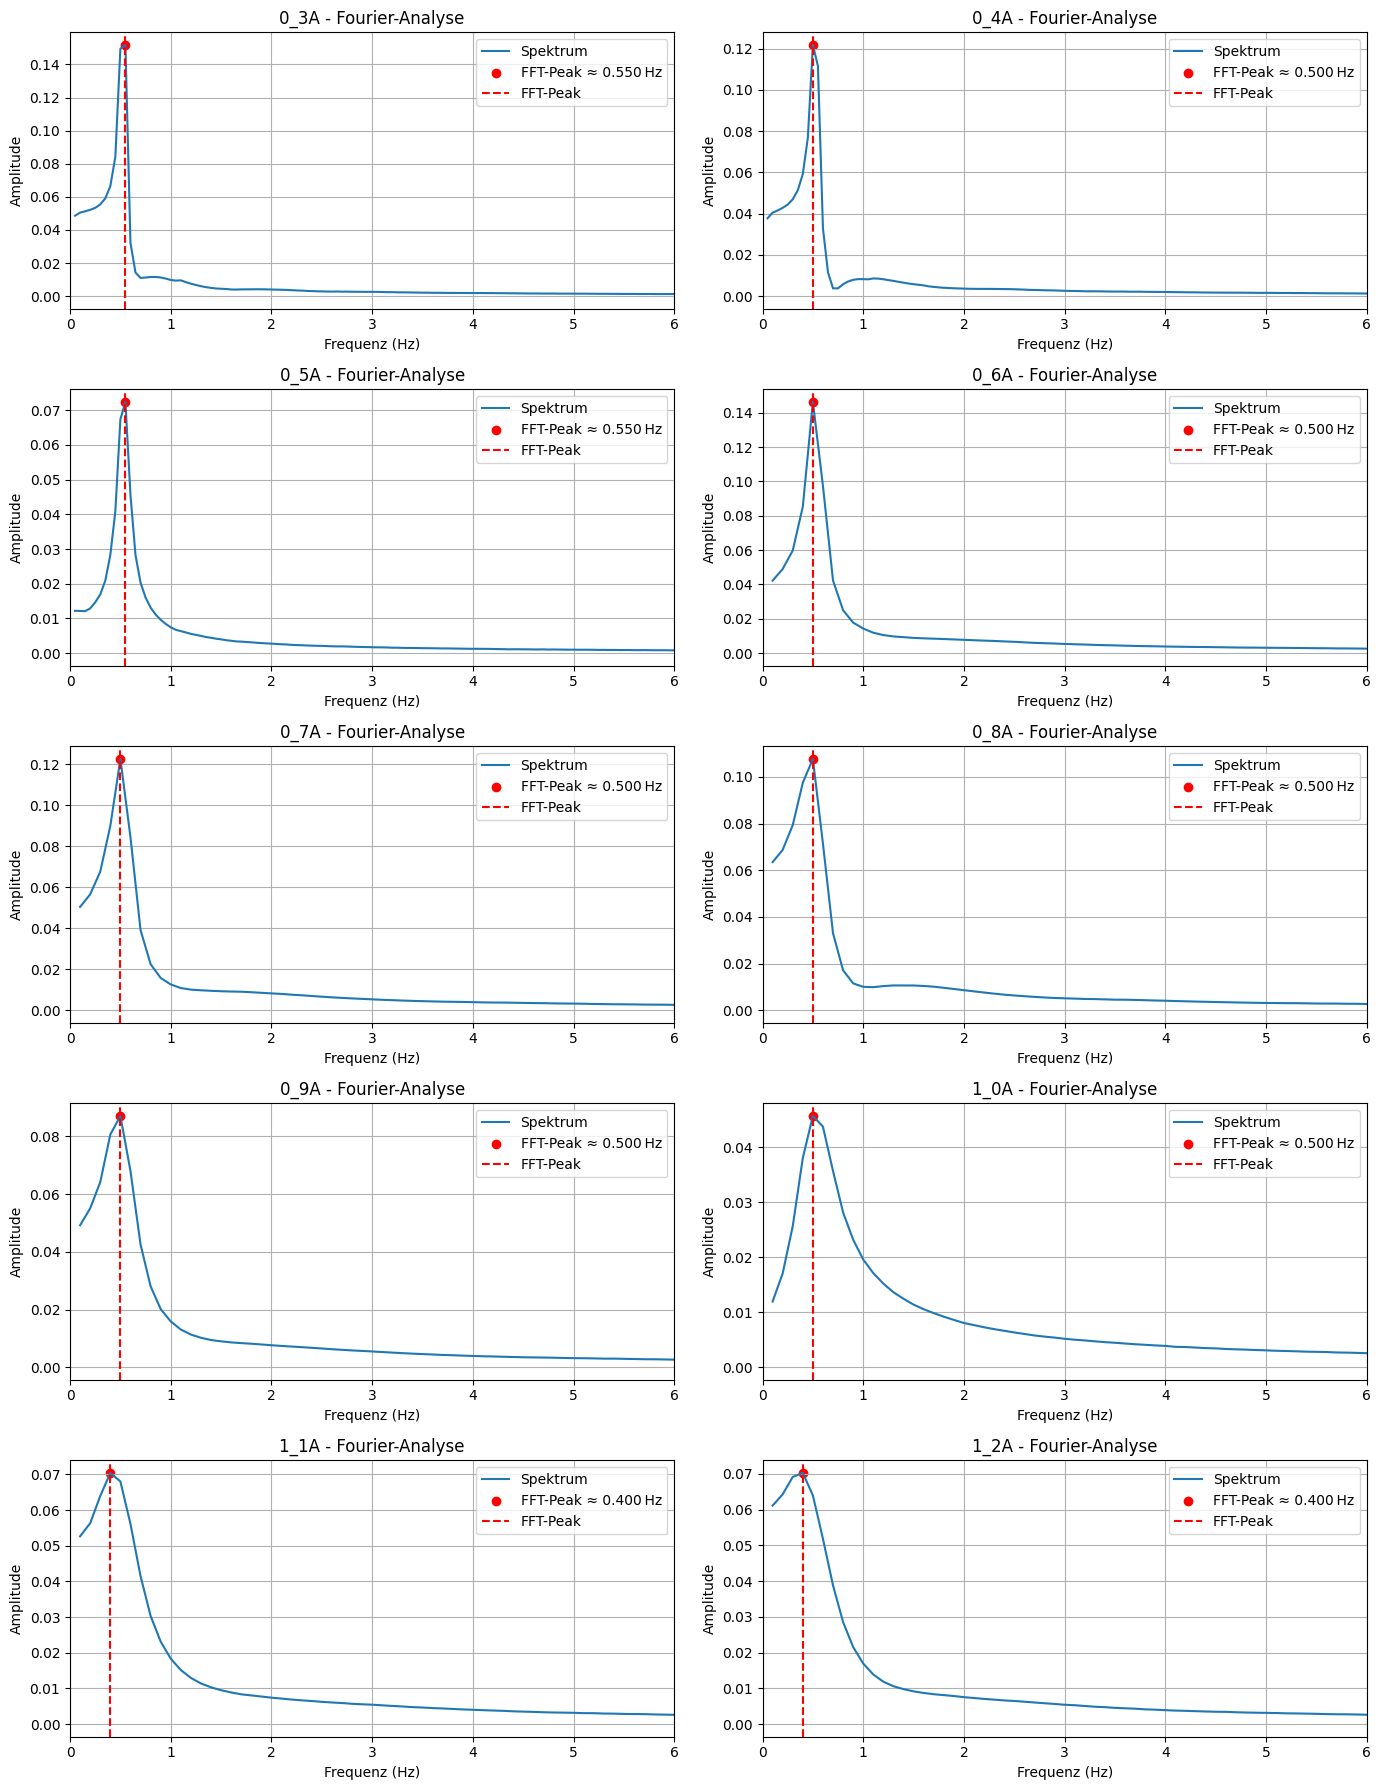

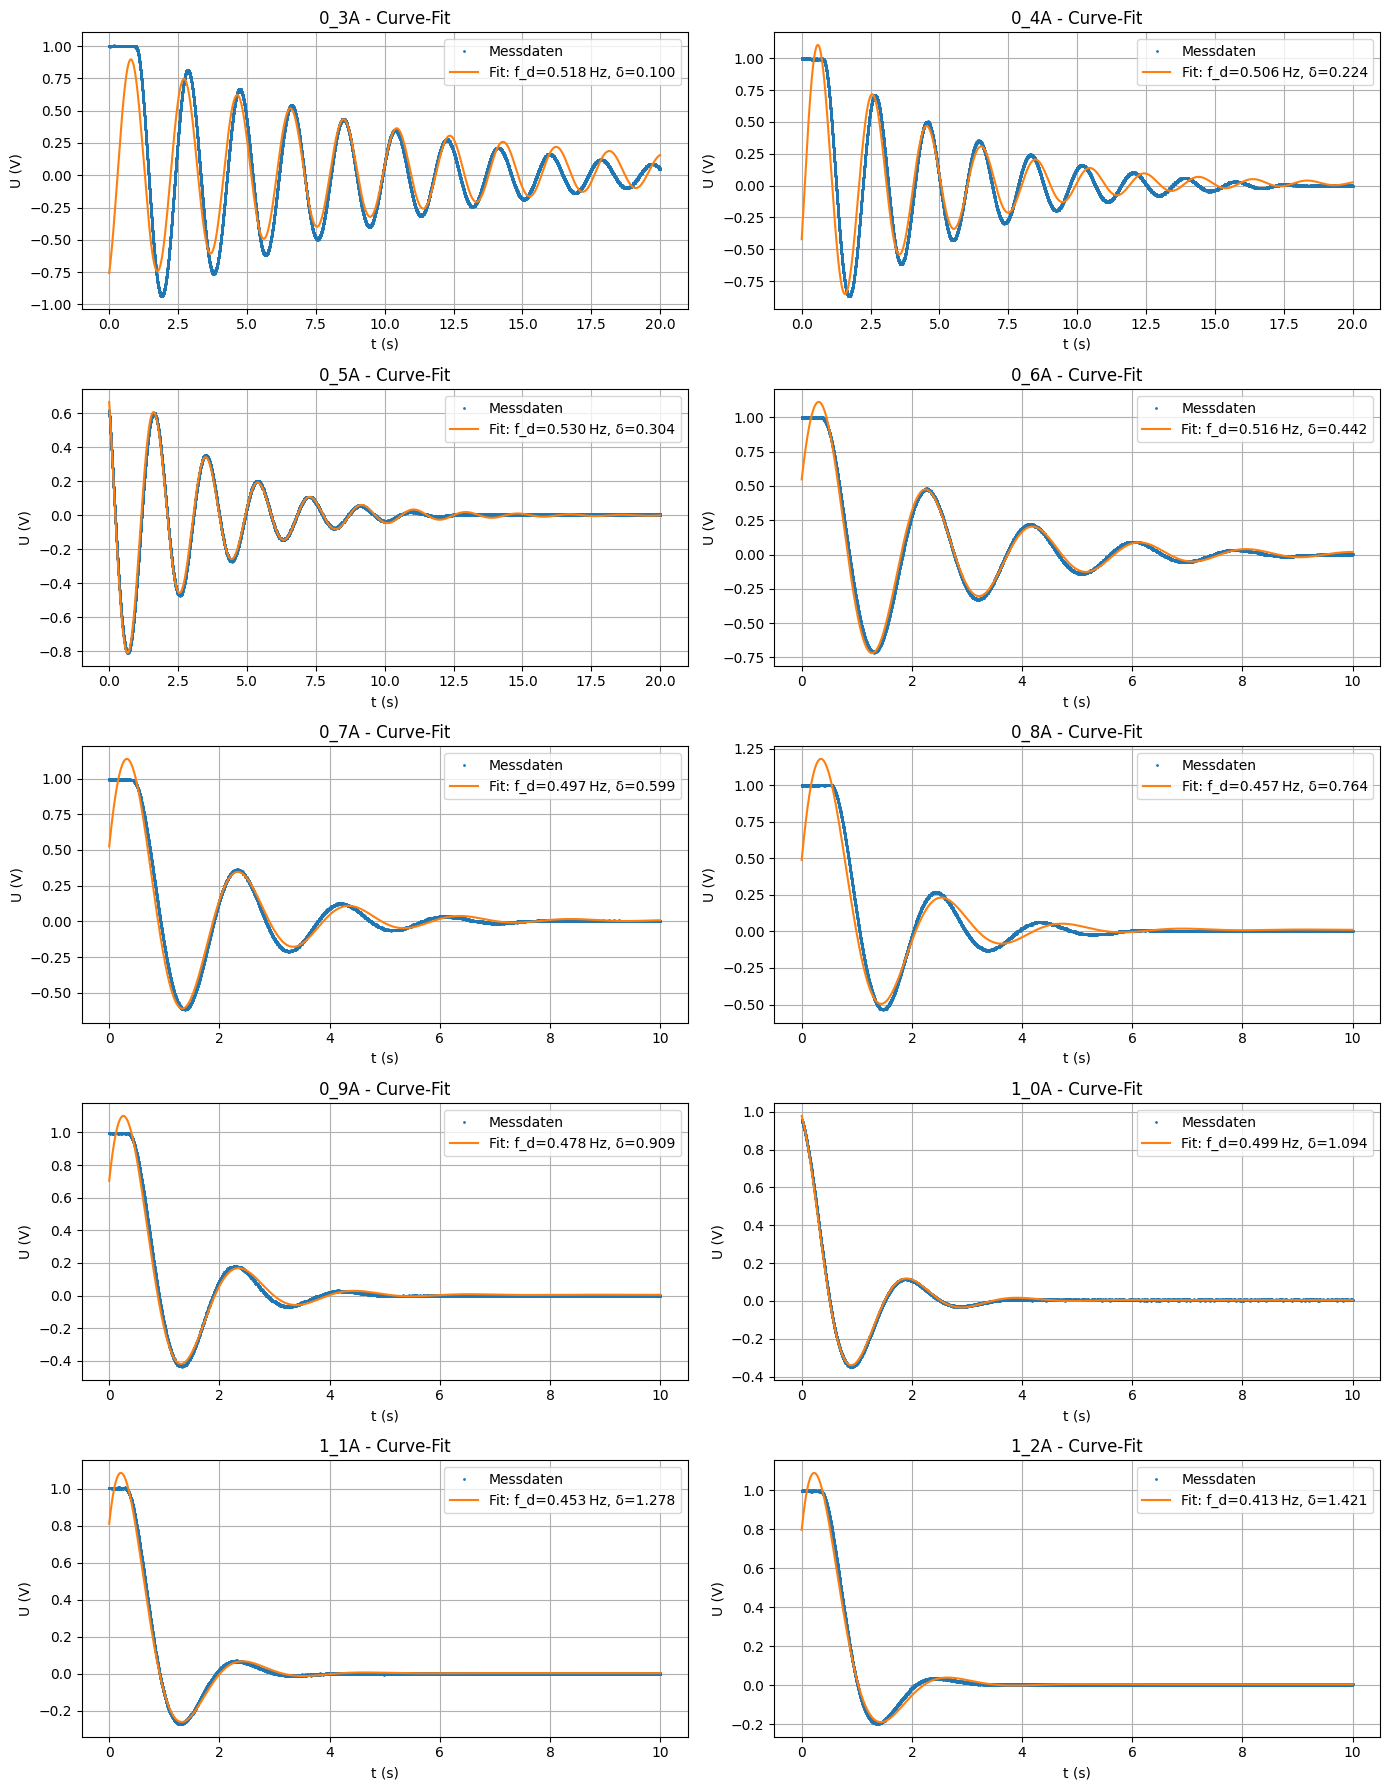

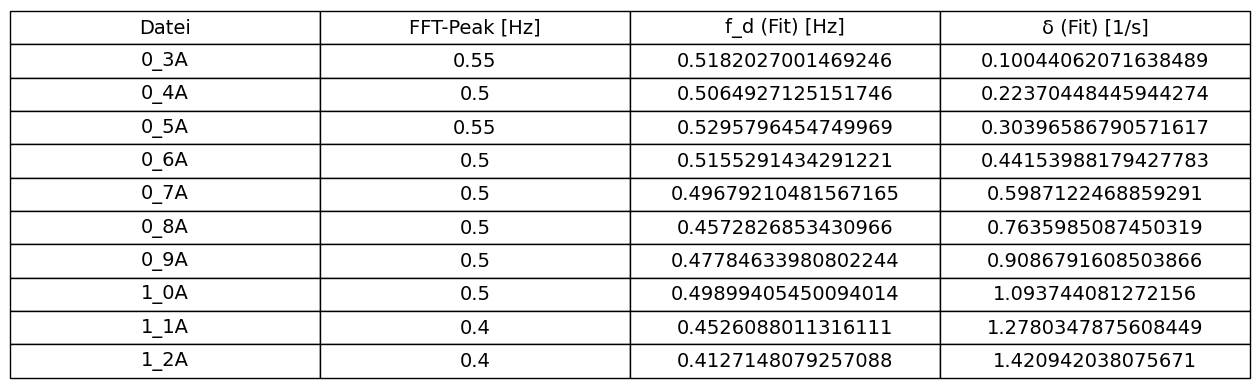

In [ ]:
# | label: fig-plot-fft
# | fig-cap: 
# |     - "Fourier-Analyse der Messungen"
# |     - "Curve-Fit an die gedämpfte Sinusfunktion"
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from natsort import natsorted

# ------------------------
# Hilfsfunktionen
# ------------------------

def damped_sinus_function(t, A, delta, omega_d, phase, offset):
    """Gedämpfte Sinusfunktion: A·e^(-delta t)·sin(ω_d t + φ) + offset"""
    return A * np.exp(-delta * t) * np.sin(omega_d * t + phase) + offset

def estimate_omega_fft(t, y):
    """Grobe Abschätzung von ω_d per FFT-Peak"""
    dt = np.mean(np.diff(t))
    n = len(t)
    f = fftfreq(n, d=dt)
    Y = fft(y - np.mean(y))
    # nur positive Frequenzen betrachten
    mask = f > 0
    f_pos = f[mask]
    Ypos = np.abs(Y[mask])
    idx_peak = np.argmax(Ypos)
    freq_peak = f_pos[idx_peak]
    return 2 * np.pi * freq_peak, freq_peak

def fit_damped_sinus(t, y, omega_guess):
    """Curve‑Fit an die gedämpfte Sinusfunktion"""
    A0     = (np.max(y) - np.min(y)) / 2
    delta0 = 0.1         # Startwert Dämpfung
    phi0   = 0.0
    off0   = np.mean(y)
    p0 = [A0, delta0, omega_guess, phi0, off0]
    
    params, cov = curve_fit(
        damped_sinus_function, t, y,
        p0=p0, maxfev=10_000, 
        bounds=([0, 0,      0,   -2*np.pi, -np.inf],
                [np.inf, np.inf, np.inf, 2*np.pi, np.inf])
    )
    return params, cov

# ------------------------
# Daten einlesen
# ------------------------

folder = "M10_Aufgabe_1_Daten"
# Datei-Liste natur­sor­tiert (0_3, 0_4, …, 1_2)
files = natsorted([f for f in os.listdir(folder) if re.match(r'\d+_\dA_Aufgabe_1_M10.txt', f)])

results = []

# ------------------------
# Plot-Vorbereitung
# ------------------------
fig_fft, axes_fft = plt.subplots(5, 2, figsize=(14, 18))
axes_fft = axes_fft.flatten()

fig_fit, axes_fit = plt.subplots(5, 2, figsize=(14, 18))
axes_fit = axes_fit.flatten()

# ------------------------
# Schleife über alle Dateien
# ------------------------
for idx, fn in enumerate(files):
    # Datei einlesen
    path = os.path.join(folder, fn)
    df = pd.read_csv(path, sep='\t', names=["t", "U"], skiprows=1)
    t = df["t"].values
    U = df["U"].values
    
    # 1) FFT-Analyse
    omega_fft, f_fft = estimate_omega_fft(t, U)
    # Berechne Spektrum für Plot
    dt = np.mean(np.diff(t))
    n = len(t)
    f = fftfreq(n, d=dt)
    Y = fft(U - np.mean(U))
    mask = f > 0
    f_pos = f[mask]
    amp = np.abs(Y[mask]) / n
    
    # Peak-Markierung
    peaks_idx, _ = find_peaks(amp, height=np.max(amp)*0.1)
    # nur den höchsten Peak auswählen
    main_peak = peaks_idx[np.argmax(amp[peaks_idx])]
    
    # Plot FFT
    ax = axes_fft[idx]
    ax.plot(f_pos, amp, label="Spektrum")
    ax.scatter(f_pos[main_peak], amp[main_peak], color='red',
               label=f"FFT-Peak ≈ {f_pos[main_peak]:.3f} Hz")
    ax.set_xlim(0, 6)
    ax.set_xlabel("Frequenz (Hz)")
    ax.set_ylabel("Amplitude")
    ax.set_title(fn.replace(".txt","")[:4] + " - Fourier-Analyse")
    ax.axvline(f_pos[main_peak], color='red', linestyle='--', label="FFT-Peak")
    ax.legend()
    ax.grid(True)
    
    # 2) Curve‑Fit an gedämpfte Sinusfunktion
    params, cov = fit_damped_sinus(t, U, omega_fft)
    A_fit, delta_fit, omega_d_fit, phi_fit, off_fit = params
    f_d_fit = omega_d_fit / (2*np.pi)
    
    # Plot Fit vs. Daten
    U_fit = damped_sinus_function(t, *params)
    ax2 = axes_fit[idx]
    ax2.plot(t, U, '.', markersize=2, label="Messdaten")
    ax2.plot(t, U_fit, '-', label=f"Fit: f_d={f_d_fit:.3f} Hz, δ={delta_fit:.3f}")
    ax2.set_xlabel("t (s)")
    ax2.set_ylabel("U (V)")
    ax2.set_title(fn.replace(".txt","")[:4] + " - Curve-Fit")
    ax2.legend()
    ax2.grid(True)
    
    # Ergebnis sammeln
    results.append({
        "Stromstärke über Spulen": fn[:4],
        "FFT-Peak [Hz]": f_fft,
        "f_d (Fit) [Hz]": f_d_fit,
        "δ (Fit) [1/s]": delta_fit
    })

# ------------------------
# Ausgabe der Ergebnisse
# ------------------------
fig_table, axes_table = plt.subplots()
# hide axes
fig_table.patch.set_visible(False)
axes_table.axis('off')
axes_table.axis('tight')

# Ergebnisse in DataFrame umwandeln
res_df = pd.DataFrame(results)
#print("\nErgebnisse zusammengefasst:")
#print(res_df.to_string(index=False))

# Tabelle mit größerer Schrift und größerem Zellenabstand für bessere Lesbarkeit
table = axes_table.table(
    cellText=res_df.values,
    colLabels=res_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(2.5, 2)  # (width, height) Skalierung der Tabelle

# ------------------------
# Layout & Show
# ------------------------
fig_fft.tight_layout()
fig_fit.tight_layout()
plt.show()